
# Cell-crawling BTP prototype - Version 0

###Purpose:
    First computational milestone inspired by
    "Minimal Physical Model Captures Shapes of Crawling Cells".

###IMPORTANT:
    This is NOT yet a reproduction of the full paper.
    It is a deliberately small quasi-2D prototype:
      - phi(x,y,t) is a diffuse phase field representing the cell.
      - a prescribed active velocity represents treadmilling.
      - the phase field relaxes through a double-well + gradient-energy model.
      - activity is stronger toward the leading edge, producing translation
        and deformation/protrusion.

Next versions will replace the prescribed velocity with the paper's
polarization field P and then add active stress / fluid dynamics.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Numerical parameters
N = 160
L = 80.0
dx = L / N
dt = 0.005
steps = 3000

In [ ]:
# Phase-field parameters
radius = 18.0
interface_width = 2.0
relaxation = 0.8

# Treadmilling/activity strength
w0 = 2.0

# Save snapshots for an animation-like diagnostic plot
snapshot_steps = [0, 750, 1500, 2250, 2999]

##The Laplacian
$$\nabla^2 a \approx \frac{a_{i+1, j} + a_{i-1, j} + a_{i, j+1} + a_{i, j-1} - 4a_{i, j}}{\Delta x^2}$$

In [ ]:
def laplacian(a):
    """Second-order periodic finite-difference Laplacian."""
    return (
        np.roll(a, 1, axis=0)
        + np.roll(a, -1, axis=0)
        + np.roll(a, 1, axis=1)
        + np.roll(a, -1, axis=1)
        - 4.0 * a
    ) / dx**2

Central Difference Method

You know:

$$ f'(x_i) \approx \frac{f_{i+1}-f_{i-1}}{2\Delta x}. $$

That's exactly what we're doing.

So:
$$\frac{\partial \phi}{\partial x} \approx \frac{\phi_{i+1, j} - \phi_{i-1, j}}{2\Delta x}$$

In [ ]:
def gradient_x(a):
    """Second-order central derivative in x."""
    return (np.roll(a, -1, axis=0) - np.roll(a, 1, axis=0)) / (2.0 * dx)

In [ ]:
def initialize_phase_field(X, Y):
    """Smooth circular droplet: phi~1 inside, phi~0 outside."""
    r = np.sqrt(X**2 + Y**2)
    return 0.5 * (
        1.0 - np.tanh((r - radius) / (np.sqrt(2.0) * interface_width))
    )

In [ ]:
def active_velocity(X):
    """
    Prescribed treadmilling velocity.

    It is intentionally stronger toward the +x leading edge.
    This is a temporary stand-in for the paper's w0*P term.
    """
    leading_edge_factor = 0.5 * (
        1.0 + np.tanh((X - 2.0) / 6.0)
    )
    return w0 * (0.2 + 0.8 * leading_edge_factor)

In [ ]:
def run():
    x = np.linspace(-L / 2.0, L / 2.0, N)
    y = np.linspace(-L / 2.0, L / 2.0, N)
    X, Y = np.meshgrid(x, y, indexing="ij")

    phi = initialize_phase_field(X, Y)
    snapshots = []

    for step in range(steps):
        ux = active_velocity(X)

        # Advection by active treadmilling:
        #     dphi/dt + ux*dphi/dx = ...
        advection = ux * gradient_x(phi)

        # Chemical-potential-like term from a simple phase-field energy:
        #
        # F = integral [ eps^2/2 |grad(phi)|^2
        #                + 1/2 phi^2(1-phi)^2 ] dA
        #
        # delta F/delta phi =
        #       -eps^2 laplacian(phi)
        #       + phi(phi-1)(2phi-1)
        chemical_potential = (
            -interface_width**2 * laplacian(phi)
            + phi * (phi - 1.0) * (2.0 * phi - 1.0)
        )

        # Explicit Euler update.
        phi += dt * (
            -advection
            - relaxation * chemical_potential
        )

        # Numerical safety.
        phi = np.clip(phi, 0.0, 1.0)

        if step in snapshot_steps:
            snapshots.append((step, phi.copy()))

    return X, Y, snapshots, phi


In [ ]:
def plot_results(X, Y, snapshots):
    fig, axes = plt.subplots(1, len(snapshots), figsize=(15, 3.2))

    for ax, (step, phi) in zip(axes, snapshots):
        im = ax.imshow(
            phi.T,
            origin="lower",
            extent=[X.min(), X.max(), Y.min(), Y.max()],
            vmin=0.0,
            vmax=1.0,
        )
        ax.set_title(f"step = {step}")
        ax.set_xlabel("x")
        ax.set_aspect("equal")

    axes[0].set_ylabel("y")
    fig.colorbar(im, ax=axes, shrink=0.8, label=r"$\phi$")
    fig.suptitle("Cell-crawling prototype: active phase-field model")
    fig.tight_layout()
    plt.show()

/tmp/ipykernel_3523/87736479.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


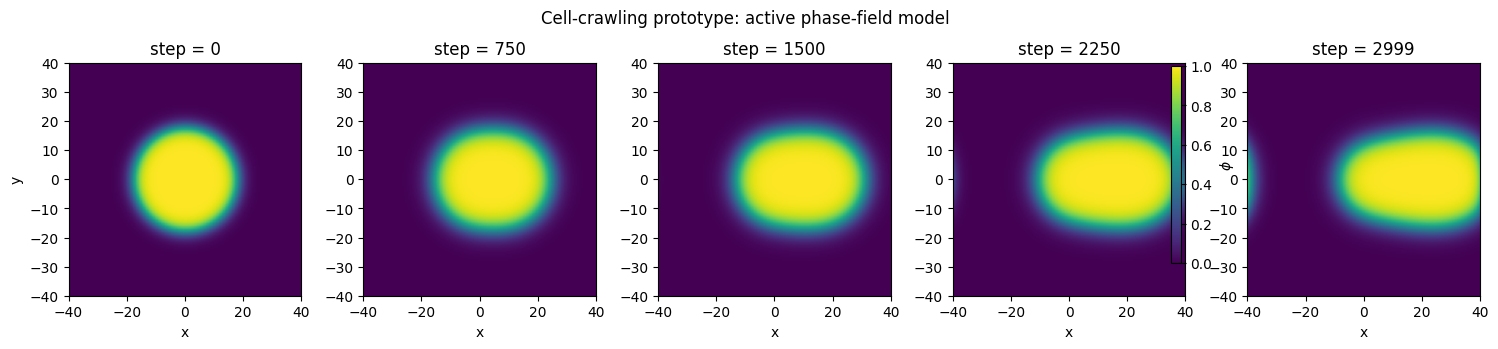

In [ ]:
if __name__ == "__main__":
    X, Y, snapshots, _ = run()
    plot_results(X, Y, snapshots)